In [1]:
import os
import sys

import math
import time
import datetime
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view
import torch
from torch.utils.data import Dataset
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torch.optim.lr_scheduler import CosineAnnealingLR
# from YourDataset import YourDataset  # Import your custom dataset here
from tqdm import tqdm
from torch.cuda.amp import autocast, GradScaler
from torchinfo import summary
import torchprofile
import h5py

from utils.architecture import Unet
from utils.diffusion import ElucidatedDiffusion

torch.manual_seed(23)
import pickle

DTYPE = torch.float32

scaler = GradScaler()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 200
plt.rcParams["font.family"] = "serif"

import scipy.stats as stats
from scipy.interpolate import griddata

/oscar/home/voommen/apps/torch_env/lib64/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [2]:
def error_metric(pred,true, Par):
    #re-normalize
    # true = true*Par['out_scale'] + Par['out_shift']
    # true = true*Par['out_scale'] + Par['out_shift']
    return torch.norm(true-pred, p=2)/torch.norm(true, p=2)

class MyDataset(Dataset):
    def __init__(self, x, y, transform=None):
        self.x = x
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        x_sample = self.x[idx]
        y_sample = self.y[idx]

        if self.transform:
            x_sample, y_sample = self.transform(x_sample, y_sample)

        return x_sample, y_sample
    
def preprocess(x,y, Par):
    # x = sliding_window_view(x[:,Par['lb']-1:,:,:], window_shape=Par['lf'], axis=1 ).transpose(0,1,4,2,3).reshape(-1,Par['lf'],Par['nx'], Par['ny'])
    # y = sliding_window_view(y[:,Par['lb']-1:,:,:], window_shape=Par['lf'], axis=1 ).transpose(0,1,4,2,3).reshape(-1,Par['lf'],Par['nx'], Par['ny'])

    # x,y - [BS, LF, nf, nth, nx, ny]
    x = x.transpose(0,1,3,2,4,5) #[BS, LF, nth, nf, nx, ny]
    y = y.transpose(0,1,3,2,4,5) #[BS, LF, nth, nf, nx, ny]


    x = x.reshape(-1, Par['nf'], Par['nx'], Par['ny'])
    y = y.reshape(-1, Par['nf'], Par['nx'], Par['ny'])

    print('x: ', x.shape)
    print('y: ', y.shape)
    print()
    return x,y

In [3]:
res = 128
begin_time = time.time()
# inp = np.load(f"/oscar/data/gk/voommen/no_diffusion/kolmogrov/res_{res}/matcho/Y_PRED.npy") #low-fidelity
# out = np.load(f"/oscar/data/gk/voommen/no_diffusion/kolmogrov/res_{res}/matcho/Y_TRUE.npy") #high-fidelity
x_train = np.load("../TRAIN_PRED.npy") #[BS, LF, nf, nth, nr, nx]
y_train = np.load("../TRAIN_TRUE.npy")

x_val = np.load("../VAL_PRED.npy")
y_val = np.load("../VAL_TRUE.npy")

x_test = np.load("../TEST_PRED.npy")
y_test = np.load("../TEST_TRUE.npy")
print(f"Data Loading Time: {time.time() - begin_time:.1f}s")



# Train-Val-Test Split
# idx1 = int(0.8 * inp.shape[0])
# idx2 = int(0.9 * inp.shape[0])

# x_train = inp[:idx1]
# x_val   = inp[idx1:idx2]
# x_test  = inp[idx2:]

# y_train = out[:idx1]
# y_val   = out[idx1:idx2]
# y_test  = out[idx2:]



inp_min = np.load("../../data/MIN_vel.npy").reshape(1,1,-1,1,1,1)
inp_max = np.load("../../data/MAX_vel.npy").reshape(1,1,-1,1,1,1)
out_min = np.load("../../data/MIN_vel.npy").reshape(1,1,-1,1,1,1)
out_max = np.load("../../data/MAX_vel.npy").reshape(1,1,-1,1,1,1)



Par = {"inp_shift" : torch.tensor(inp_min, dtype=DTYPE, device=device),
       "inp_scale" : torch.tensor(inp_max - inp_min, dtype=DTYPE, device=device),
       "out_shift" : torch.tensor(out_min, dtype=DTYPE, device=device),
       "out_scale" : torch.tensor(out_max - out_min, dtype=DTYPE, device=device),
       "nf"        : x_train.shape[2],
       "nth"       : x_train.shape[3],
       "nx"        : x_train.shape[4],
       "ny"        : x_train.shape[5],
       "lb"        : 1,
       "lf"        : 1,
       "num_epochs": 100000
       }

# Normalizing the data to [0,1]
shift = Par['inp_shift'].detach().cpu().numpy()
scale = Par['inp_scale'].detach().cpu().numpy()
x_train = (x_train - shift)/scale
x_val = (x_val - shift)/scale
x_test = (x_test - shift)/scale

shift = Par['out_shift'].detach().cpu().numpy()
scale = Par['out_scale'].detach().cpu().numpy()
y_train = (y_train - shift)/scale
y_val = (y_val - shift)/scale
y_test = (y_test - shift)/scale

Par["sigma_data"] = np.std(y_train)

# Traj splitting
begin_time = time.time()
print('\nTrain Dataset')
x_train, y_train = preprocess(x_train, y_train, Par)
print('\nValidation Dataset')
x_val, y_val = preprocess(x_val, y_val, Par)
print('\nTest Dataset')
x_test, y_test = preprocess(x_test, y_test, Par)
print(f"Data Preprocess Time: {time.time() - begin_time:.1f}s")

Par.update({"channels"       : x_train.shape[1],
            "self_condition" : True
            })

print("Par")
with open('Par.pkl', 'wb') as f:
    pickle.dump(Par, f)

x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

x_val_tensor   = torch.tensor(x_val,   dtype=torch.float32)
y_val_tensor   = torch.tensor(y_val,   dtype=torch.float32)

x_test_tensor  = torch.tensor(x_test,  dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test,  dtype=torch.float32)

train_dataset = MyDataset(x_train_tensor, y_train_tensor)
val_dataset = MyDataset(x_val_tensor, y_val_tensor)
test_dataset = MyDataset(x_test_tensor, y_test_tensor)

# Define data loaders
train_batch_size = 640 #16
val_batch_size   = 640
test_batch_size  = 640
train_loader = DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=val_batch_size)
test_loader = DataLoader(test_dataset, batch_size=test_batch_size)

print(f"train loader: {len(train_loader)}")
print(f"val loader: {len(val_loader)}")
print(f"test loader: {len(test_loader)}")


Data Loading Time: 96.9s

Train Dataset
x:  (252800, 3, 32, 128)
y:  (252800, 3, 32, 128)


Validation Dataset
x:  (28800, 3, 32, 128)
y:  (28800, 3, 32, 128)


Test Dataset
x:  (28800, 3, 32, 128)
y:  (28800, 3, 32, 128)

Data Preprocess Time: 39.8s
Par
train loader: 395
val loader: 45
test loader: 45


In [4]:
# Define Network Architecture
net = Unet(
    dim = 16,
    dim_mults = (1, 2, 4, 8),
    channels = Par["channels"],
    self_condition = Par["self_condition"],
    flash_attn = True
).to(device).to(torch.float32)
summary(net, input_size=((1,)+x_train.shape[1:], (1,)) )

model = ElucidatedDiffusion(net,
                                channels = Par["channels"],
                                image_size_h=Par["nx"],
                                image_size_w=Par["ny"],
                                sigma_data=Par["sigma_data"])

path_model = 'models/best_model.pt'
# path_model = 'models/model_100.pt'
model.load_state_dict(torch.load(path_model))

Non-A100 GPU detected, using math or mem efficient attention if input tensor is on cuda


<All keys matched successfully>

In [5]:
l_fidel_ls = []
y_pred_ls = []
y_true_ls = []

counter = 0

model.eval()
test_loss = 0.0
with torch.no_grad():
    for l_fidel, h_fidel in test_loader:
        with autocast():
            pred = model.sample(l_fidel.to(device), num_sample_steps=32)
            loss   = error_metric(pred, h_fidel.to(device), Par)
        test_loss += loss.item()
        l_fidel_ls.append(l_fidel)
        y_true_ls.append(h_fidel)
        y_pred_ls.append(pred)
        counter = counter+1

test_loss /= counter#len(test_loader)
print(f'Test Loss: {test_loss:.4e}')

sampling time step: 100%|██████████| 32/32 [00:04<00:00,  7.14it/s]

Test Loss: 1.1261e-01


In [6]:
y_true = torch.cat(y_true_ls, dim=0).detach().cpu().numpy().reshape(-1, 10, Par['nth'], Par['nf'], Par["nx"], Par["ny"]).transpose(0,1,3,2,4,5)
y_pred = torch.cat(y_pred_ls, dim=0).detach().cpu().numpy().reshape(-1, 10, Par['nth'], Par['nf'], Par["nx"], Par["ny"]).transpose(0,1,3,2,4,5)
y_no   = torch.cat(l_fidel_ls, dim=0).detach().cpu().numpy().reshape(-1, 10, Par['nth'], Par['nf'], Par["nx"], Par["ny"]).transpose(0,1,3,2,4,5)

# Renormalize from [0,1] to actual distribution
y_true = y_true * Par['out_scale'].detach().cpu().numpy() + Par['out_shift'].detach().cpu().numpy()
y_pred = y_pred * Par['out_scale'].detach().cpu().numpy() + Par['out_shift'].detach().cpu().numpy()
y_no   = y_no   * Par['inp_scale'].detach().cpu().numpy() + Par['inp_shift'].detach().cpu().numpy()

print(f"y_true: {y_true.shape}")
print(f"y_pred: {y_pred.shape}")
print(f"y_no  : {y_no.shape}")

y_true: (90, 10, 3, 32, 32, 128)
y_pred: (90, 10, 3, 32, 32, 128)
y_no  : (90, 10, 3, 32, 32, 128)


In [27]:
# np.save("true_visual.npy", y_true[0,4])
# np.save("no_visual.npy", y_no[0,4])
# np.save("pred_visual.npy", y_pred[0,4])

In [13]:
np.save("true_visual_t4.npy", y_true[0,3])
np.save("true_visual_t8.npy", y_true[0,7])

np.save("no_visual_t4.npy", y_no[0,3])
np.save("no_visual_t8.npy", y_no[0,7])

np.save("pred_visual_t4.npy", y_pred[0,3])
np.save("pred_visual_t8.npy", y_pred[0,7])

# The saved files were visualized using tecplot

In [11]:
np.save("true_visual_full.npy", y_true[:,4])
np.save("no_visual_full.npy", y_no[:,4])
np.save("pred_visual_full.npy", y_pred[:,4])

In [10]:
t_ls = np.linspace(0,25,51)[4:]
t_ls

array([ 2. ,  2.5,  3. ,  3.5,  4. ,  4.5,  5. ,  5.5,  6. ,  6.5,  7. ,
        7.5,  8. ,  8.5,  9. ,  9.5, 10. , 10.5, 11. , 11.5, 12. , 12.5,
       13. , 13.5, 14. , 14.5, 15. , 15.5, 16. , 16.5, 17. , 17.5, 18. ,
       18.5, 19. , 19.5, 20. , 20.5, 21. , 21.5, 22. , 22.5, 23. , 23.5,
       24. , 24.5, 25. ])


p: 0
(32, 32, 128)
[4 8]


/tmp/ipykernel_2593648/4159117018.py:231: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.9, 1])


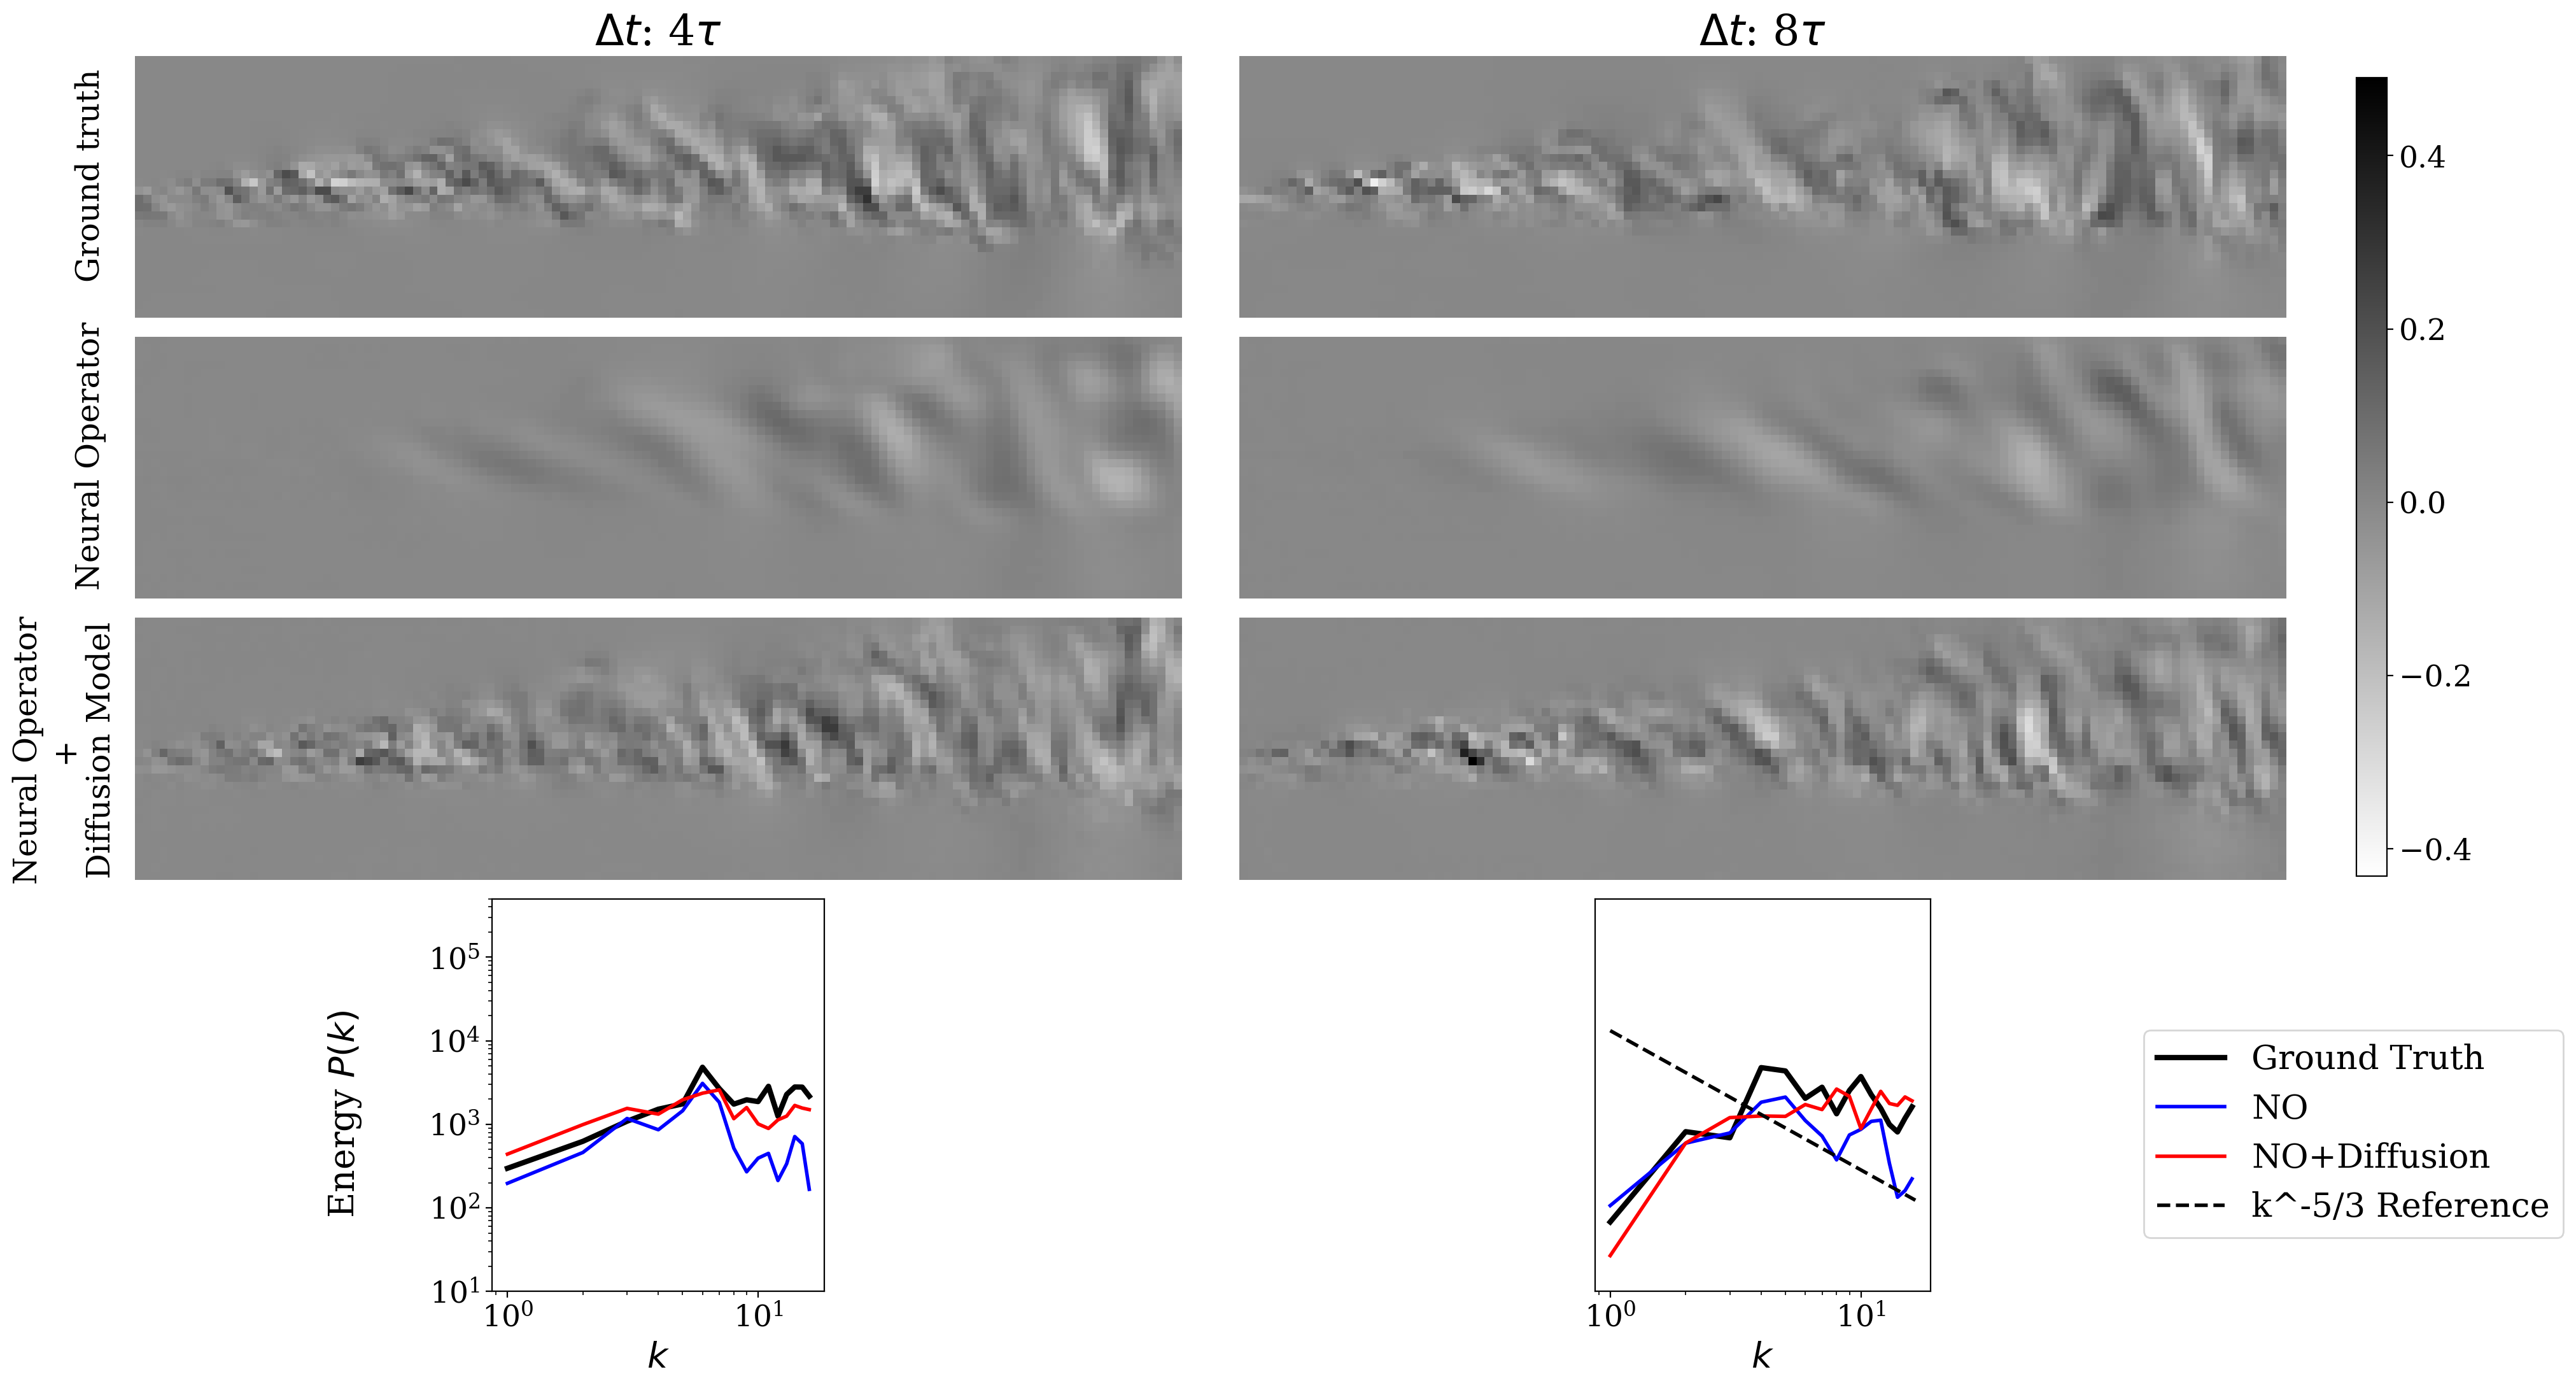

In [32]:
for p in [0]:
    print()
    print(f"p: {p}")
    sample_id = p
    skip_t = 5
    f_no = 0
    t_ls = ((np.arange(11)[1:]))
    t_idx = [3,7]
    true = y_true[sample_id][t_idx][f_no,0]
    pred1 = y_no[sample_id][t_idx][f_no,0]
    pred2 = y_pred[sample_id][t_idx][f_no,0]
    time_ls = t_ls[t_idx]

    
    
    print(true.shape)
    print(time_ls)
    
    CMAP = 'binary' #'inferno' #'gist_heat'
    
    # Function to calculate MSE
    def mse(a, b):
        return np.mean((a - b) ** 2)
    
    def rel_l2(T, P):
        T = torch.tensor(T, dtype=DTYPE)
        P = torch.tensor(P, dtype=DTYPE)
        return torch.norm(T-P, p=2)/torch.norm(T, p=2).cpu().numpy()
    
    # Create the figure and axis
    # fig, axes = plt.subplots(4, 3, figsize=(30, 11))
    # cbar_ax = fig.add_axes([0.92, 0.3, 0.02, 0.4])  # Colorbar axis

    fig, axes = plt.subplots(4, len(time_ls), figsize=(20, 11), gridspec_kw={'height_ratios': [1, 1, 1, 1.5]})
    cbar_ax = fig.add_axes([0.9, 0.37, 0.012, 0.57])  # Adjust colorbar positioning [left, bottom, width, height]
    # cbar.ax.tick_params(labelsize=17)

    
    # Find the min and max values for colorbar
    vmin = min(true.min(), pred1.min(), pred2.min())
    vmax = max(true.max(), pred1.max(), pred2.max())

    true_temp  = np.copy(true)
    pred1_temp = np.copy(pred1)
    pred2_temp = np.copy(pred2)
    
    # true_temp[airfoil_mask == 0]  = np.nan
    # pred1_temp[airfoil_mask == 0] = np.nan
    # pred2_temp[airfoil_mask == 0] = np.nan
    
    # Plot the images
    for i in range(2):

        # Ground truth row
        im = axes[0, i].imshow(true_temp[i], origin='lower', vmin=vmin, vmax=vmax, cmap=CMAP)
        axes[0, i].set_title(r'$\Delta t$: '+f'{time_ls[i]}'+r'$\tau$', fontsize=24)
        axes[0, i].axis('off')
    
        # Prediction 1 row
        im = axes[1, i].imshow(pred1_temp[i], origin='lower', vmin=vmin, vmax=vmax, cmap=CMAP)
        # err = rel_l2(true[i], pred1[i])
        # axes[1, i].set_title(f'rel L2: {err:.2e}', fontsize=12)
        axes[1, i].axis('off')
    
        # Prediction 2 row
        im = axes[2, i].imshow(pred2_temp[i], origin='lower', vmin=vmin, vmax=vmax, cmap=CMAP)
        # err = rel_l2(true[i], pred2[i])
        # axes[2, i].set_title(f'rel L2: {err:.2e}', fontsize=12)
        axes[2, i].axis('off')
    
    
    
        #######################
    
        image = true[i]    
        ny, nx = image.shape
    
        # Compute the Fourier transform and get the amplitude squared
        fourier_image = np.fft.fftn(image)
        fourier_amplitudes = np.abs(fourier_image)**2
        
        # Create the k-frequency grid
        kfreq_y = np.fft.fftfreq(ny) * ny
        kfreq_x = np.fft.fftfreq(nx) * nx
        kfreq2D_x, kfreq2D_y = np.meshgrid(kfreq_x, kfreq_y)
        knrm = np.sqrt(kfreq2D_x**2 + kfreq2D_y**2)
        
        # Flatten the arrays to use in binning
        knrm = knrm.flatten()
        fourier_amplitudes = fourier_amplitudes.flatten()
        
        # Define the bins for the wavenumber
        kbins = np.arange(0.5, min(nx, ny)//2+1, 1.)
        kvals = 0.5 * (kbins[1:] + kbins[:-1])
        
        # Bin the data
        Abins, _, _ = stats.binned_statistic(knrm, fourier_amplitudes,
                                             statistic="mean",
                                             bins=kbins)
        
        # Scale the binned amplitudes
        Abins *= np.pi * (kbins[1:]**2 - kbins[:-1]**2)
        
        # Plotting    
        axes[3, i].loglog(kvals, Abins, c='black', label="Ground Truth", linewidth=3)
    
    
        
        image = pred1[i]    
        ny, nx = image.shape
    
        # Compute the Fourier transform and get the amplitude squared
        fourier_image = np.fft.fftn(image)
        fourier_amplitudes = np.abs(fourier_image)**2
        
        # Create the k-frequency grid
        kfreq_y = np.fft.fftfreq(ny) * ny
        kfreq_x = np.fft.fftfreq(nx) * nx
        kfreq2D_x, kfreq2D_y = np.meshgrid(kfreq_x, kfreq_y)
        knrm = np.sqrt(kfreq2D_x**2 + kfreq2D_y**2)
        
        # Flatten the arrays to use in binning
        knrm = knrm.flatten()
        fourier_amplitudes = fourier_amplitudes.flatten()
        
        # Define the bins for the wavenumber
        kbins = np.arange(0.5, min(nx, ny)//2+1, 1.)
        kvals = 0.5 * (kbins[1:] + kbins[:-1])
        
        # Bin the data
        Abins, _, _ = stats.binned_statistic(knrm, fourier_amplitudes,
                                             statistic="mean",
                                             bins=kbins)
        
        # Scale the binned amplitudes
        Abins *= np.pi * (kbins[1:]**2 - kbins[:-1]**2)    
        
        
        # Plotting    
        axes[3, i].loglog(kvals, Abins, label="NO", c='blue', linewidth=2)
    
    
    
    
        image = pred2[i]    
        ny, nx = image.shape
    
        # Compute the Fourier transform and get the amplitude squared
        fourier_image = np.fft.fftn(image)
        fourier_amplitudes = np.abs(fourier_image)**2
        
        # Create the k-frequency grid
        kfreq_y = np.fft.fftfreq(ny) * ny
        kfreq_x = np.fft.fftfreq(nx) * nx
        kfreq2D_x, kfreq2D_y = np.meshgrid(kfreq_x, kfreq_y)
        knrm = np.sqrt(kfreq2D_x**2 + kfreq2D_y**2)
        
        # Flatten the arrays to use in binning
        knrm = knrm.flatten()
        fourier_amplitudes = fourier_amplitudes.flatten()
        
        # Define the bins for the wavenumber
        kbins = np.arange(0.5, min(nx, ny)//2+1, 1.)
        kvals = 0.5 * (kbins[1:] + kbins[:-1])
            
        # Bin the data
        Abins, _, _ = stats.binned_statistic(knrm, fourier_amplitudes,
                                             statistic="mean",
                                             bins=kbins)
        
        # Scale the binned amplitudes
        Abins *= np.pi * (kbins[1:]**2 - kbins[:-1]**2)    
        
        
        # Plotting    
        axes[3, i].loglog(kvals, Abins, label="NO+Diffusion", c='red', linewidth=2)

        axes[3, i].set_ylim(10**1,5*10**5)

        for ax in axes[3, :]:  # Adjusting only the last row axes
            ax.tick_params(axis='both', which='major', labelsize=17)
        
        if i!=0:
            axes[3,i].get_yaxis().set_visible(False)
    
    
        
    
        # Adding the -5/3 slope line
        k_ref = np.linspace(1, np.max(kbins), 100)  # Range of wavenumber for the reference line
        energy_ref = k_ref**(-5/3)  # Energy corresponding to the -5/3 slope
        energy_ref *= max(Abins) / max(energy_ref)  # Normalize to plot scale    
    
        axes[3, i].set_xlabel('$k$', fontsize=20)
        if i == 1:
            axes[3, i].loglog(k_ref, 5*energy_ref, 'k--', label='k^-5/3 Reference', linewidth=2)
            leg = axes[3, i].legend()
            # axes[3, i1].legend(loc='upper \left', bbox_to_anchor=(1.05, 1), frameon=False)
            handles, labels = axes[3, i].get_legend_handles_labels()

            # Remove the original legend from the axes
            leg.remove()
            
            # Define custom coordinates for the new legend (adjust these values to your liking)
            custom_x = 0.81  # Adjust this value to move left-right
            custom_y = 0.10  # Adjust this value to move up-down
            
            # Create a new standalone legend at the custom coordinates on the figure
            fig.legend(handles, labels, loc='lower left', bbox_to_anchor=(custom_x, custom_y), fontsize=19)


        # axes[3,i].set_aspect(1/3)
        axes[3,i].set_aspect(1/3)
    
        ################## 
    
        
    
    
    
    
    
    # Add row labels
    # Add row labels
    fig.text(0.01, 0.87, 'Ground truth', va='center', ha='center', rotation='vertical', fontsize=18)
    fig.text(0.01, 0.67, 'Neural Operator', va='center', ha='center', rotation='vertical', fontsize=18)
    fig.text(-0.00, 0.46, 'Neural Operator\n+\nDiffusion Model', va='center', ha='center', rotation='vertical', fontsize=18)
    fig.text(0.11, 0.20, r'Energy $P(k)$', va='center', ha='center', rotation='vertical', fontsize=20)
    
    # Adjust layout
    fig.tight_layout(rect=[0, 0, 0.9, 1])
    # fig.colorbar(im, cax=cbar_ax)
    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.ax.tick_params(labelsize=17)
    plt.show()

# Plotting the power spectrum

In [21]:
import os
import sys

import math
import time
import datetime
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view
import torch
from torch.utils.data import Dataset
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torch.optim.lr_scheduler import CosineAnnealingLR
# from YourDataset import YourDataset  # Import your custom dataset here
from tqdm import tqdm
from torch.cuda.amp import autocast, GradScaler
from torchinfo import summary
import torchprofile
import h5py

from utils.architecture import Unet
from utils.diffusion import ElucidatedDiffusion

torch.manual_seed(23)
import pickle

DTYPE = torch.float32

scaler = GradScaler()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 200
plt.rcParams["font.family"] = "serif"

import scipy.stats as stats
from scipy.interpolate import griddata, interpn

Using device: cuda


In [29]:
def get_vel_mag(data):
    # Load grid and data
    file = h5py.File(f'../../data/jet_grid.h5', 'r')
    x_grid = file["x"][:256][::2].astype(np.float64)  # Cartesian X
    r_grid = file["r"][:64][::2].astype(np.float64)#[2:]   # Cylindrical r
    theta_grid = file["theta"][::2][::2].astype(np.float64)  # Cylindrical theta
    
    # Create meshgrid in cylindrical coordinates
    x, r, theta = np.meshgrid(x_grid, r_grid, theta_grid, indexing='ij')
    
    # Load velocity data
    ux = data[2].transpose(2, 1, 0)#[:,2:]
    ur = data[1].transpose(2, 1, 0)#[:,2:]
    uth = data[0].transpose(2, 1, 0)#[:,2:]
    
    
    # Convert velocity components to Cartesian coordinates
    velocity_x = ux
    velocity_y = ur * np.cos(theta) - uth * np.sin(theta)
    velocity_z = ur * np.sin(theta) + uth * np.cos(theta)
    
    # Convert the cylindrical coordinates to Cartesian coordinates
    X = x
    Y = r * np.cos(theta)
    Z = r * np.sin(theta)

    #interpolating to regular grid for FFT
    # Define the regular Cartesian grid for interpolation
    x_min, x_max = X.min(), X.max()
    y_min, y_max = Y.min(), Y.max()
    z_min, z_max = Z.min(), Z.max()
    
    # Define the desired resolution for the grid
    num_points_x = 128  # Modify based on your resolution needs
    num_points_y = 128
    num_points_z = 128
    x_lin = np.linspace(x_min, x_max, num_points_x)
    y_lin = np.linspace(y_min, y_max, num_points_y)
    z_lin = np.linspace(z_min, z_max, num_points_z)
    
    # Create a regular meshgrid in Cartesian coordinates
    X_reg, Y_reg, Z_reg = np.meshgrid(x_lin, y_lin, z_lin, indexing='ij')
    
    # Flatten the irregular grid points and velocity vectors
    points = np.column_stack((X.ravel(), Y.ravel(), Z.ravel()))
    velocity_vectors = np.column_stack((velocity_x.ravel(), velocity_y.ravel(), velocity_z.ravel()))
    
    # Interpolate the velocity components onto the regular meshgrid
    velocity_x_interp = griddata(points, velocity_vectors[:, 0], (X_reg, Y_reg, Z_reg), method='nearest')
    velocity_y_interp = griddata(points, velocity_vectors[:, 1], (X_reg, Y_reg, Z_reg), method='nearest')
    velocity_z_interp = griddata(points, velocity_vectors[:, 2], (X_reg, Y_reg, Z_reg), method='nearest')
    
    
    X = X_reg
    Y = Y_reg
    Z = Z_reg
    
    velocity_x = velocity_x_interp
    velocity_y = velocity_y_interp
    velocity_z = velocity_z_interp

    velocity_mag = np.sqrt(velocity_x**2 + velocity_y**2 + velocity_z**2)

    return velocity_mag

In [30]:
true_t4 = np.load("true_visual_t4.npy")
true_t8 = np.load("true_visual_t8.npy")

no_t4 = np.load("no_visual_t4.npy")
no_t8 = np.load("no_visual_t8.npy")

pred_t4 = np.load("pred_visual_t4.npy")
pred_t8 = np.load("pred_visual_t8.npy")

In [31]:
true_mag_t4 = get_vel_mag(true_t4) #[nx, nr, nth]
print(true_mag_t4.shape)
true_mag_t8 = get_vel_mag(true_t8)

no_mag_t4 = get_vel_mag(no_t4)
no_mag_t8 = get_vel_mag(no_t8)

pred_mag_t4 = get_vel_mag(pred_t4)
pred_mag_t8 = get_vel_mag(pred_t8)


(128, 128, 128)


In [32]:
D = 1
Ny = 128
Nx = 128

Lx = Ly = 2.78*D

delta_x = Lx/Nx
delta_y = Ly/Ny

k_x_nq = np.pi/delta_x
k_y_nq = np.pi/delta_y
k_nq   = min(k_x_nq, k_y_nq)

print(f"k_x_nq: {k_x_nq}")
print(f"k_y_nq: {k_y_nq}")
print(f"k_nq: {k_y_nq}")


k_x_nq: 144.6488703811128
k_y_nq: 144.6488703811128
k_nq: 144.6488703811128


(3, 128, 128)


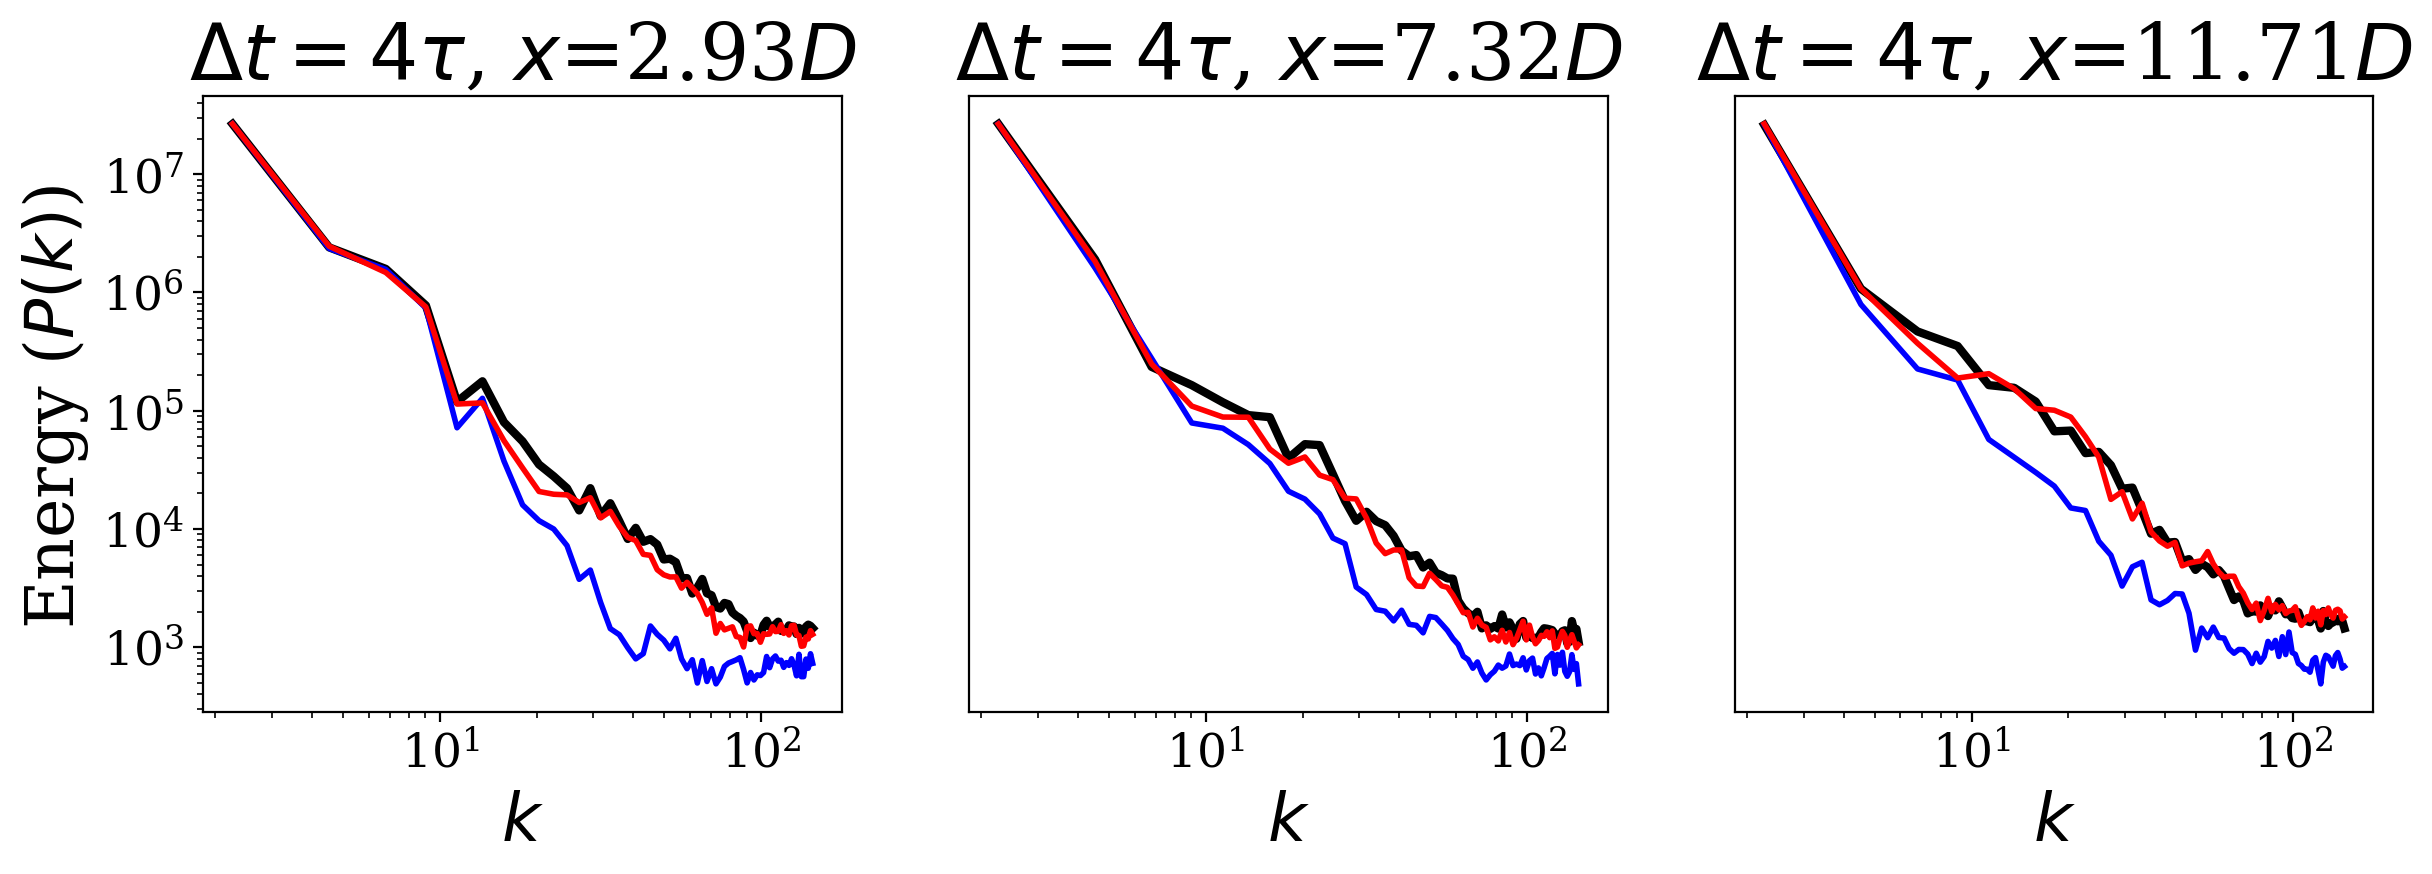

In [70]:
x_idx = [31,79,127]
true  = true_mag_t4[x_idx]
pred1 = no_mag_t4[x_idx]
pred2 = pred_mag_t4[x_idx]

print(true.shape)

fig, axes = plt.subplots(1,3, figsize=(14, 4) )


for i in range(true.shape[0]):
    image = true[i]    
    ny, nx = image.shape
    
    # Compute the Fourier transform and get the amplitude squared
    fourier_image = np.fft.fftn(image)
    fourier_amplitudes = np.abs(fourier_image)**2
    
    # Create the k-frequency grid
    kfreq_y = np.fft.fftfreq(ny) * ny
    kfreq_x = np.fft.fftfreq(nx) * nx
    kfreq2D_x, kfreq2D_y = np.meshgrid(kfreq_x, kfreq_y)
    knrm = np.sqrt(kfreq2D_x**2 + kfreq2D_y**2)
    
    # Flatten the arrays to use in binning
    knrm = knrm.flatten()
    fourier_amplitudes = fourier_amplitudes.flatten()
    
    # Define the bins for the wavenumber
    kbins = np.arange(0.5, min(nx, ny)//2+1, 1.)
    kvals = 0.5 * (kbins[1:] + kbins[:-1])
    kvals = kvals / (0.5*min(nx, ny)) * k_nq
    
    
    # Bin the data
    Abins, _, _ = stats.binned_statistic(knrm, fourier_amplitudes,
                                         statistic="mean",
                                         bins=kbins)
    
    # Scale the binned amplitudes
    Abins *= np.pi * (kbins[1:]**2 - kbins[:-1]**2)
    
    # Plotting    
    axes[i].loglog(kvals, Abins, c='black', label="Ground Truth", linewidth=3)
    
    
    
    image = pred1[i]    
    ny, nx = image.shape
    
    # Compute the Fourier transform and get the amplitude squared
    fourier_image = np.fft.fftn(image)
    fourier_amplitudes = np.abs(fourier_image)**2
    
    # Create the k-frequency grid
    kfreq_y = np.fft.fftfreq(ny) * ny
    kfreq_x = np.fft.fftfreq(nx) * nx
    kfreq2D_x, kfreq2D_y = np.meshgrid(kfreq_x, kfreq_y)
    knrm = np.sqrt(kfreq2D_x**2 + kfreq2D_y**2)
    
    # Flatten the arrays to use in binning
    knrm = knrm.flatten()
    fourier_amplitudes = fourier_amplitudes.flatten()
    
    # Define the bins for the wavenumber
    kbins = np.arange(0.5, min(nx, ny)//2+1, 1.)
    kvals = 0.5 * (kbins[1:] + kbins[:-1])
    kvals = kvals / (0.5*min(nx, ny)) * k_nq
    
    # Bin the data
    Abins, _, _ = stats.binned_statistic(knrm, fourier_amplitudes,
                                         statistic="mean",
                                         bins=kbins)
    
    # Scale the binned amplitudes
    Abins *= np.pi * (kbins[1:]**2 - kbins[:-1]**2)    
    
    
    # Plotting    
    axes[i].loglog(kvals, Abins, label="NO", c='blue', linewidth=2)
    
    
    
    
    image = pred2[i]    
    ny, nx = image.shape
    
    # Compute the Fourier transform and get the amplitude squared
    fourier_image = np.fft.fftn(image)
    fourier_amplitudes = np.abs(fourier_image)**2
    
    # Create the k-frequency grid
    kfreq_y = np.fft.fftfreq(ny) * ny
    kfreq_x = np.fft.fftfreq(nx) * nx
    kfreq2D_x, kfreq2D_y = np.meshgrid(kfreq_x, kfreq_y)
    knrm = np.sqrt(kfreq2D_x**2 + kfreq2D_y**2)
    
    # Flatten the arrays to use in binning
    knrm = knrm.flatten()
    fourier_amplitudes = fourier_amplitudes.flatten()
    
    # Define the bins for the wavenumber
    kbins = np.arange(0.5, min(nx, ny)//2+1, 1.)
    kvals = 0.5 * (kbins[1:] + kbins[:-1])
    kvals = kvals / (0.5*min(nx, ny)) * k_nq
        
    # Bin the data
    Abins, _, _ = stats.binned_statistic(knrm, fourier_amplitudes,
                                         statistic="mean",
                                         bins=kbins)
    
    # Scale the binned amplitudes
    Abins *= np.pi * (kbins[1:]**2 - kbins[:-1]**2)    
    
    
    # Plotting    
    axes[i].loglog(kvals, Abins, label="NO+Diffusion", c='red', linewidth=2)
    
    # axes[i].set_ylim(9*10**2,2*10**8)
    
    for ax in axes[:]:  # Adjusting only the last row axes
        ax.tick_params(axis='both', which='major', labelsize=17)
    
    if i!=0:
        axes[i].get_yaxis().set_visible(False)

    if i==0:
        axes[i].set_ylabel(r"Energy ($P(k)$) ", fontsize=24)

    temp_x = (x_idx[i]+1)/128*11.71
    axes[i].set_title(r"$\Delta t=4\tau$, $x$="+f"{temp_x:.2f}"+r"$D$", fontsize=28)
    
    
    
    
    # Adding the -5/3 slope line
    k_ref = np.linspace(1, np.max(kbins), 100)  # Range of wavenumber for the reference line
    energy_ref = k_ref**(-5/3)  # Energy corresponding to the -5/3 slope
    energy_ref *= max(Abins) / max(energy_ref)  # Normalize to plot scale    
    
    axes[i].set_xlabel('$k$', fontsize=24)
    if i == 1:
        # axes[3, i].loglog(k_ref, 10*energy_ref, 'k--', label='k^-5/3 Reference', linewidth=2)
        leg = axes[i].legend()
        # axes[3, i1].legend(loc='upper \left', bbox_to_anchor=(1.05, 1), frameon=False)
        handles, labels = axes[i].get_legend_handles_labels()
    
        # Remove the original legend from the axes
        leg.remove()
        
        # Define custom coordinates for the new legend (adjust these values to your liking)
        custom_x = 0.76  # Adjust this value to move left-right
        custom_y = 0.60  # Adjust this value to move up-down
        
        # Create a new standalone legend at the custom coordinates on the figure
        # fig.legend(handles, labels, loc='lower left', bbox_to_anchor=(custom_x, custom_y), fontsize=12)

plt.show()

(3, 128, 128)


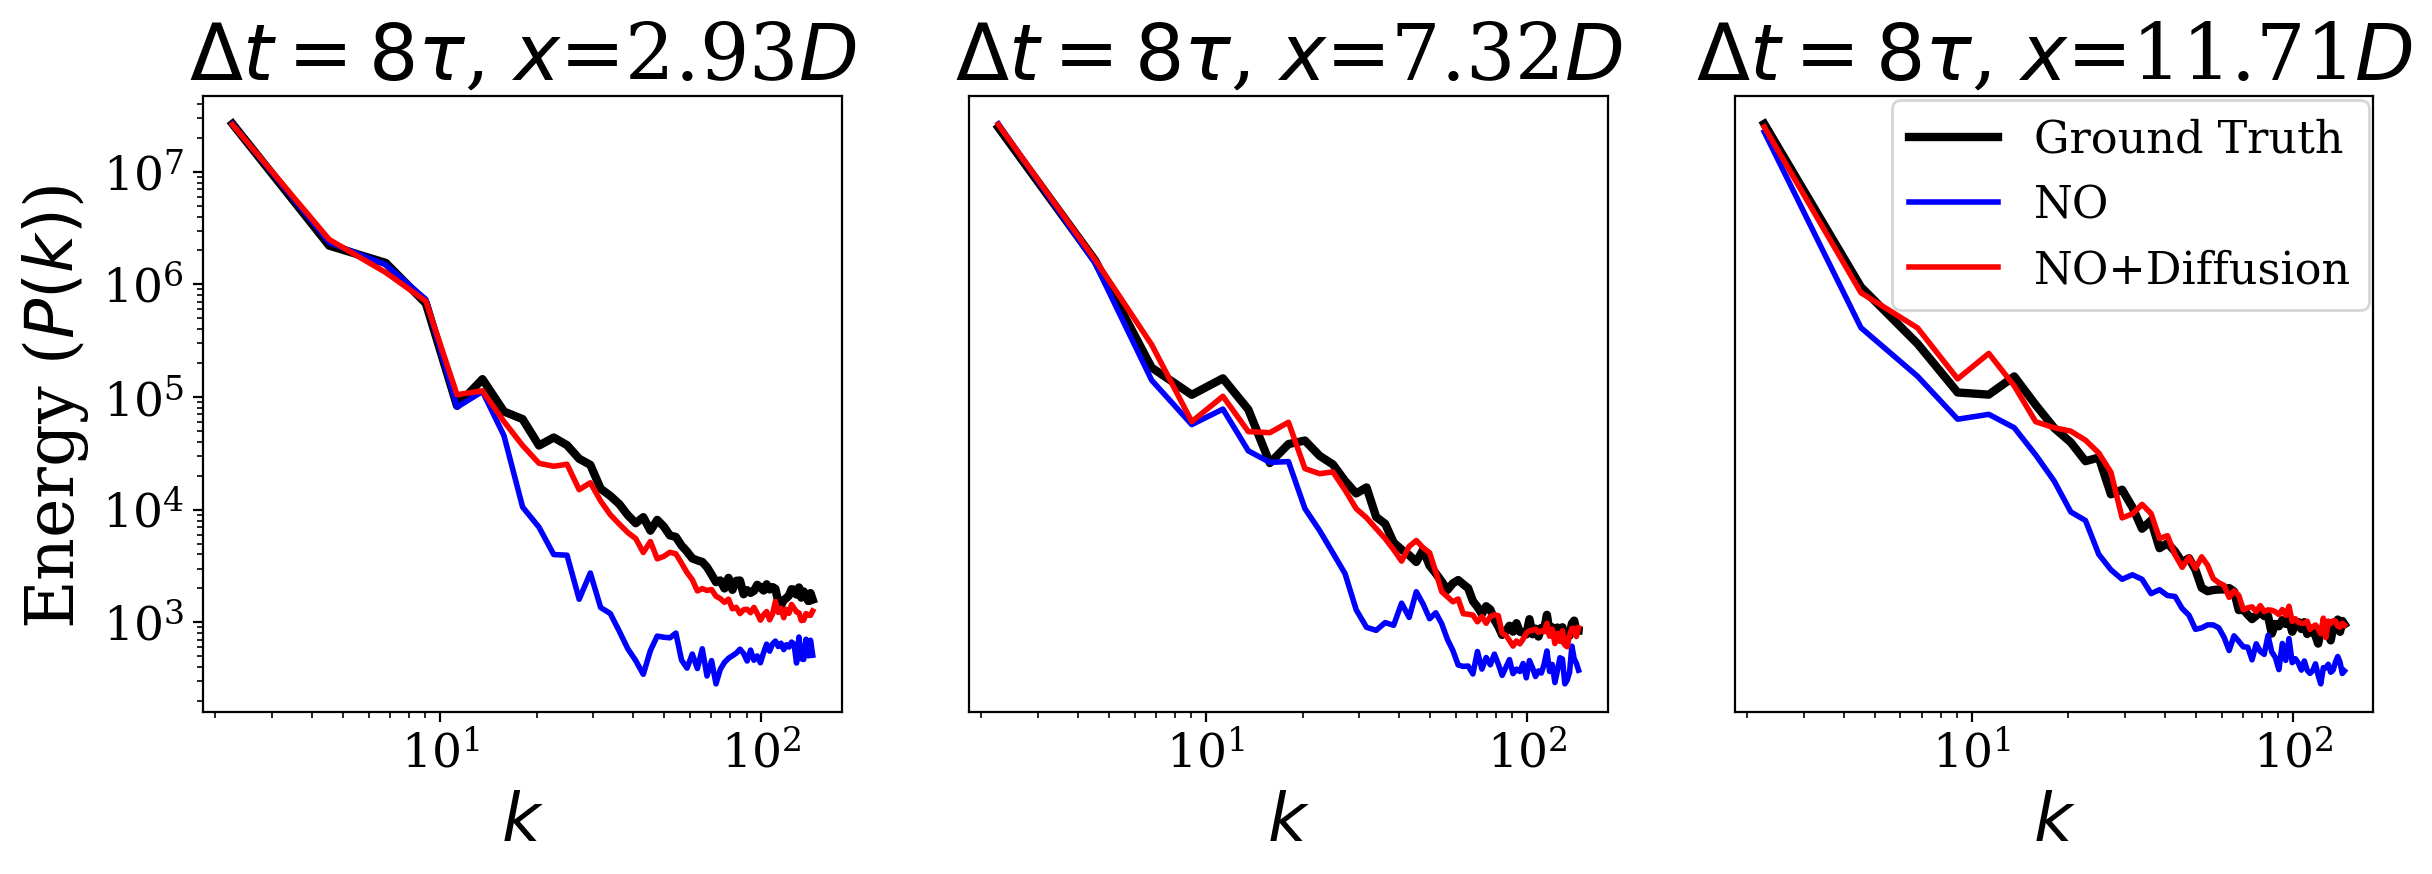

In [69]:
x_idx = [31,79,127]
true  = true_mag_t8[x_idx]
pred1 = no_mag_t8[x_idx]
pred2 = pred_mag_t8[x_idx]

print(true.shape)

fig, axes = plt.subplots(1,3, figsize=(14, 4) )


for i in range(true.shape[0]):
    image = true[i]    
    ny, nx = image.shape
    
    # Compute the Fourier transform and get the amplitude squared
    fourier_image = np.fft.fftn(image)
    fourier_amplitudes = np.abs(fourier_image)**2
    
    # Create the k-frequency grid
    kfreq_y = np.fft.fftfreq(ny) * ny
    kfreq_x = np.fft.fftfreq(nx) * nx
    kfreq2D_x, kfreq2D_y = np.meshgrid(kfreq_x, kfreq_y)
    knrm = np.sqrt(kfreq2D_x**2 + kfreq2D_y**2)
    
    # Flatten the arrays to use in binning
    knrm = knrm.flatten()
    fourier_amplitudes = fourier_amplitudes.flatten()
    
    # Define the bins for the wavenumber
    kbins = np.arange(0.5, min(nx, ny)//2+1, 1.)
    kvals = 0.5 * (kbins[1:] + kbins[:-1])
    kvals = kvals / (0.5*min(nx, ny)) * k_nq
    
    
    # Bin the data
    Abins, _, _ = stats.binned_statistic(knrm, fourier_amplitudes,
                                         statistic="mean",
                                         bins=kbins)
    
    # Scale the binned amplitudes
    Abins *= np.pi * (kbins[1:]**2 - kbins[:-1]**2)
    
    # Plotting    
    axes[i].loglog(kvals, Abins, c='black', label="Ground Truth", linewidth=3)
    
    
    
    image = pred1[i]    
    ny, nx = image.shape
    
    # Compute the Fourier transform and get the amplitude squared
    fourier_image = np.fft.fftn(image)
    fourier_amplitudes = np.abs(fourier_image)**2
    
    # Create the k-frequency grid
    kfreq_y = np.fft.fftfreq(ny) * ny
    kfreq_x = np.fft.fftfreq(nx) * nx
    kfreq2D_x, kfreq2D_y = np.meshgrid(kfreq_x, kfreq_y)
    knrm = np.sqrt(kfreq2D_x**2 + kfreq2D_y**2)
    
    # Flatten the arrays to use in binning
    knrm = knrm.flatten()
    fourier_amplitudes = fourier_amplitudes.flatten()
    
    # Define the bins for the wavenumber
    kbins = np.arange(0.5, min(nx, ny)//2+1, 1.)
    kvals = 0.5 * (kbins[1:] + kbins[:-1])
    kvals = kvals / (0.5*min(nx, ny)) * k_nq
    
    # Bin the data
    Abins, _, _ = stats.binned_statistic(knrm, fourier_amplitudes,
                                         statistic="mean",
                                         bins=kbins)
    
    # Scale the binned amplitudes
    Abins *= np.pi * (kbins[1:]**2 - kbins[:-1]**2)    
    
    
    # Plotting    
    axes[i].loglog(kvals, Abins, label="NO", c='blue', linewidth=2)
    
    
    
    
    image = pred2[i]    
    ny, nx = image.shape
    
    # Compute the Fourier transform and get the amplitude squared
    fourier_image = np.fft.fftn(image)
    fourier_amplitudes = np.abs(fourier_image)**2
    
    # Create the k-frequency grid
    kfreq_y = np.fft.fftfreq(ny) * ny
    kfreq_x = np.fft.fftfreq(nx) * nx
    kfreq2D_x, kfreq2D_y = np.meshgrid(kfreq_x, kfreq_y)
    knrm = np.sqrt(kfreq2D_x**2 + kfreq2D_y**2)
    
    # Flatten the arrays to use in binning
    knrm = knrm.flatten()
    fourier_amplitudes = fourier_amplitudes.flatten()
    
    # Define the bins for the wavenumber
    kbins = np.arange(0.5, min(nx, ny)//2+1, 1.)
    kvals = 0.5 * (kbins[1:] + kbins[:-1])
    kvals = kvals / (0.5*min(nx, ny)) * k_nq
        
    # Bin the data
    Abins, _, _ = stats.binned_statistic(knrm, fourier_amplitudes,
                                         statistic="mean",
                                         bins=kbins)
    
    # Scale the binned amplitudes
    Abins *= np.pi * (kbins[1:]**2 - kbins[:-1]**2)    
    
    
    # Plotting    
    axes[i].loglog(kvals, Abins, label="NO+Diffusion", c='red', linewidth=2)
    
    # axes[i].set_ylim(9*10**2,2*10**8)
    
    for ax in axes[:]:  # Adjusting only the last row axes
        ax.tick_params(axis='both', which='major', labelsize=17)
    
    if i!=0:
        axes[i].get_yaxis().set_visible(False)

    if i==0:
        axes[i].set_ylabel(r"Energy ($P(k)$) ", fontsize=24)

    temp_x = (x_idx[i]+1)/128*11.71
    axes[i].set_title(r"$\Delta t=8\tau$, $x$="+f"{temp_x:.2f}"+r"$D$", fontsize=28)
    
    
    
    
    # Adding the -5/3 slope line
    k_ref = np.linspace(1, np.max(kbins), 100)  # Range of wavenumber for the reference line
    energy_ref = k_ref**(-5/3)  # Energy corresponding to the -5/3 slope
    energy_ref *= max(Abins) / max(energy_ref)  # Normalize to plot scale    
    
    axes[i].set_xlabel('$k$', fontsize=24)
    if i == 1:
        # axes[3, i].loglog(k_ref, 10*energy_ref, 'k--', label='k^-5/3 Reference', linewidth=2)
        leg = axes[i].legend()
        # axes[3, i1].legend(loc='upper \left', bbox_to_anchor=(1.05, 1), frameon=False)
        handles, labels = axes[i].get_legend_handles_labels()
    
        # Remove the original legend from the axes
        leg.remove()
        
        # Define custom coordinates for the new legend (adjust these values to your liking)
        custom_x = 0.72  # Adjust this value to move left-right
        custom_y = 0.585  # Adjust this value to move up-down
        
        # Create a new standalone legend at the custom coordinates on the figure
        fig.legend(handles, labels, loc='lower left', bbox_to_anchor=(custom_x, custom_y), fontsize=16)

plt.show()

# Eigen Spectrum

In [9]:
y_true.shape

(90, 10, 3, 32, 32, 128)

In [7]:
from sklearn.decomposition import TruncatedSVD

In [20]:
def do_svd(data):
    TRAJ = data.reshape(data.shape[0], -1)
    ld = TRAJ.shape[0] #train_ld.shape[-1]
    n_components = ld-1
    
    t_svd = TruncatedSVD(n_components=n_components)
    
    us_train = t_svd.fit_transform(TRAJ)
    s_train  = t_svd.singular_values_
    v_train  = t_svd.components_
    
    error = np.abs(TRAJ - np.matmul(us_train, v_train))
    
    print('us_train: ', us_train.shape)
    print('s_train : ', s_train.shape)
    print('v_train : ', v_train.shape)
    
    print('train error')
    print('min and max error : ', np.min(error), np.max(error))
    print('mean and std error: ', np.mean(error), np.std(error))
    
    return s_train, v_train

In [48]:
t_idx = 1
sample_id = 3
f_no=0
print("TRUE")
s_true, v_true = do_svd(y_true[sample_id, :, f_no, 0])
print("\nNO")
s_no, v_no = do_svd(y_no[sample_id, :, f_no, 0])
print("\nPRED")
s_pred, v_pred = do_svd(y_pred[sample_id, :, f_no, 0])

TRUE
us_train:  (10, 9)
s_train :  (9,)
v_train :  (9, 4096)
train error
min and max error :  3.9464794e-08 0.117173
mean and std error:  0.004784259 0.009034006

NO
us_train:  (10, 9)
s_train :  (9,)
v_train :  (9, 4096)
train error
min and max error :  0.0 0.007674006
mean and std error:  0.00028890188 0.0006508944

PRED
us_train:  (10, 9)
s_train :  (9,)
v_train :  (9, 4096)
train error
min and max error :  6.065238e-08 0.14440519
mean and std error:  0.0055533266 0.0112148365


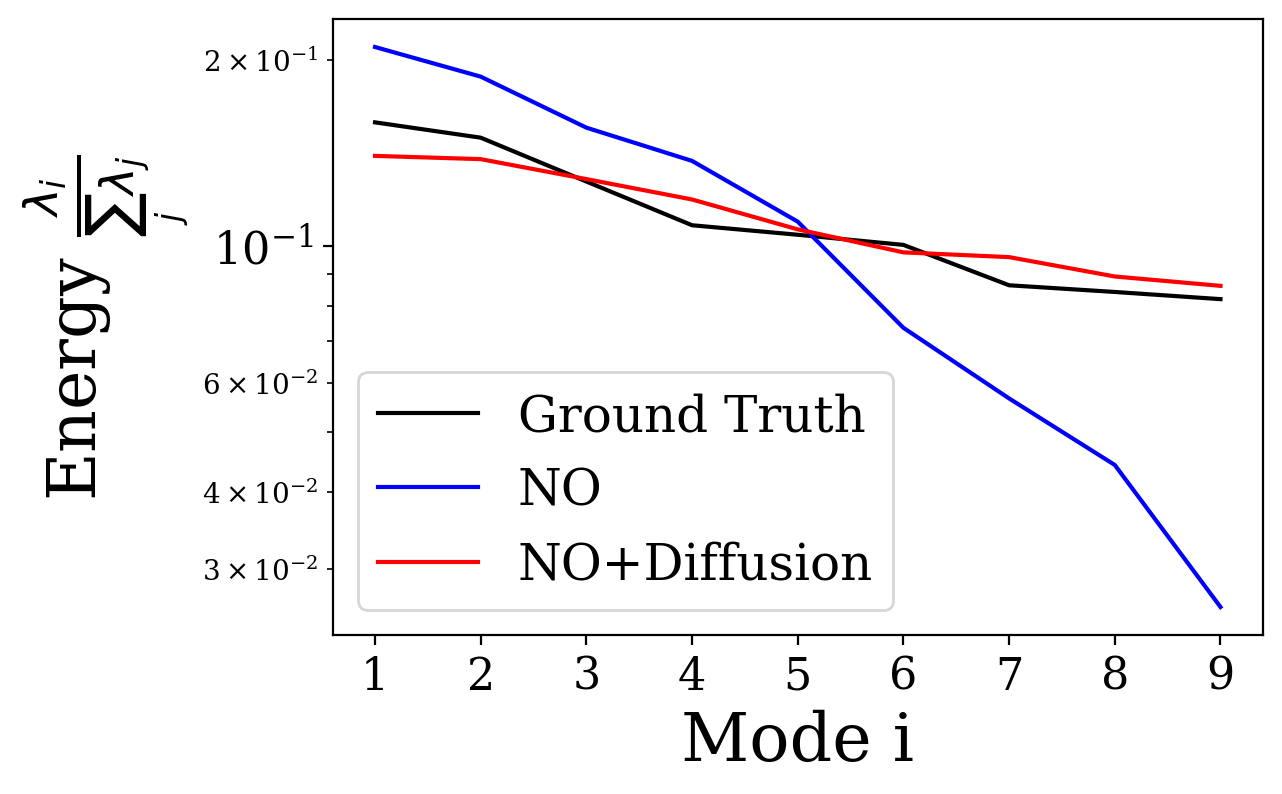

In [49]:
fig = plt.figure(figsize=(6,4))

# plt.scatter(range(1,len(s_train)+1), s_train/np.sum(s_train), s=20, facecolors='none', edgecolors='red')
plt.plot(range(1,len(s_true)+1), s_true/np.sum(s_true), c='black', label='Ground Truth')
plt.plot(range(1,len(s_no)+1), s_no/np.sum(s_no), c='blue', label='NO')
plt.plot(range(1,len(s_pred)+1), s_pred/np.sum(s_pred), c='red', label='NO+Diffusion')


plt.ylabel('Energy '+r'$\frac{\lambda_i}{\sum_j \lambda_j}$', fontsize=24)
plt.xlabel('Mode i', fontsize=24)
plt.legend(fontsize=18)
# plt.xscale('log')
plt.yscale('log')
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.show()

In [50]:
mode_idx = [0,2,4,6,8]
V_TRUE = v_true.reshape(-1, 32,128)[mode_idx]
V_NO = v_no.reshape(-1, 32,128)[mode_idx]
V_PRED = v_pred.reshape(-1, 32,128)[mode_idx]

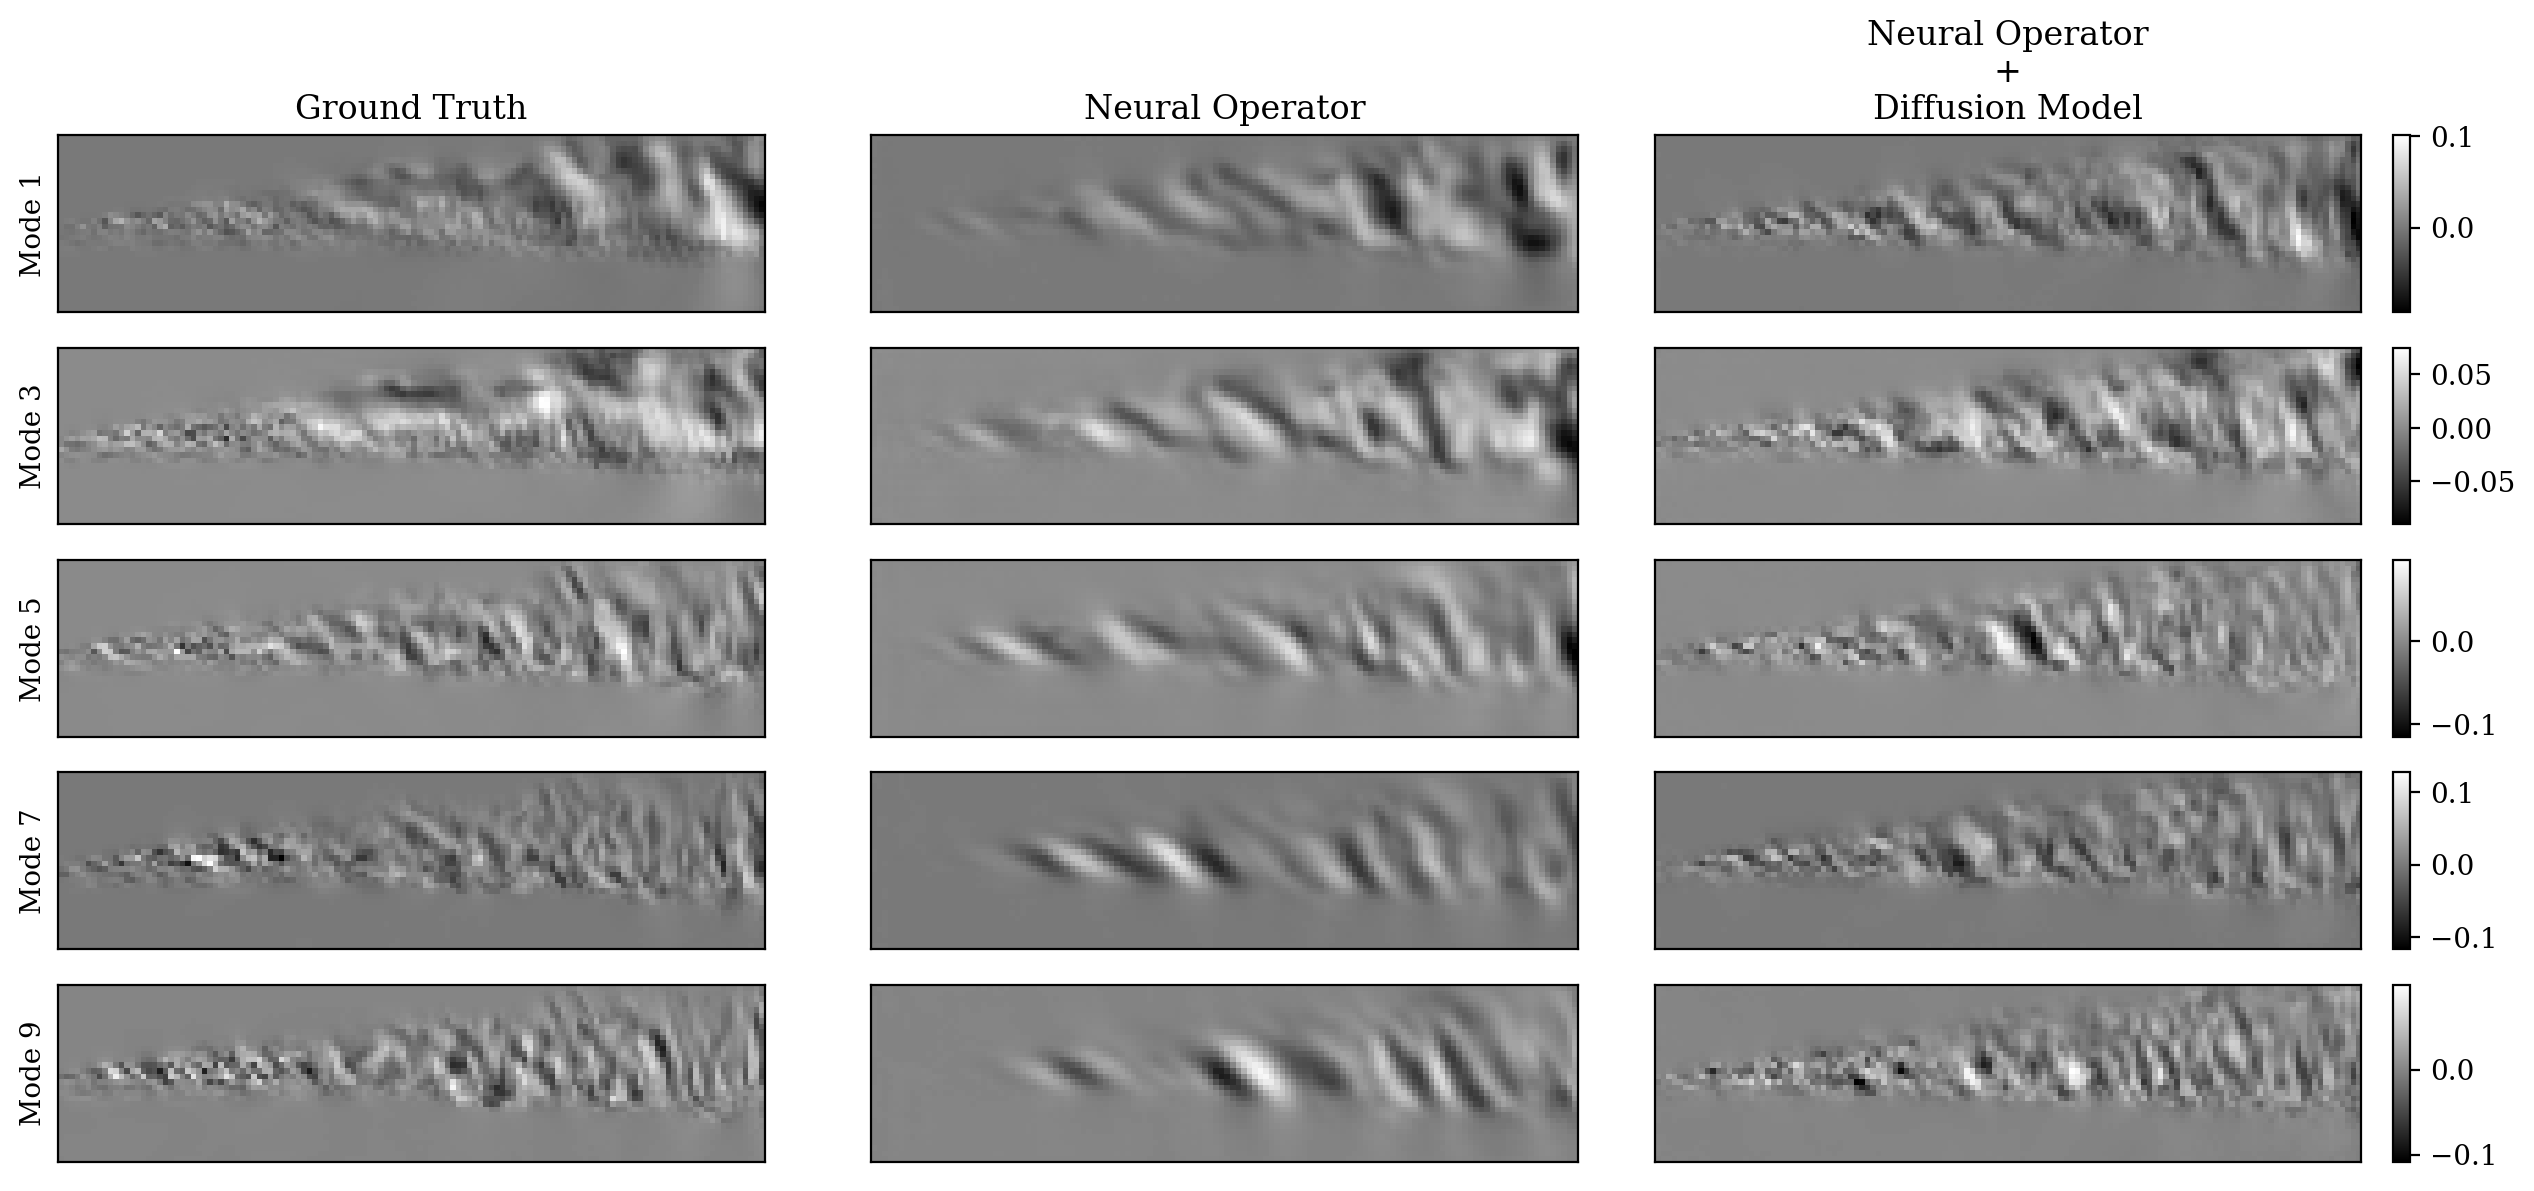

In [52]:
n = V_TRUE.shape[0]
fig, axes = plt.subplots(n, 3, figsize=(13, 6))

CMAP = "gray"


for i in range(n):
    # Plot V_TRUE
    vmin_row = min(np.min(V_TRUE[i]), np.min(V_NO[i]), np.min(V_PRED[i]))
    vmax_row = max(np.max(V_TRUE[i]), np.max(V_NO[i]), np.max(V_PRED[i]))
    
    im = axes[i,0].imshow((V_TRUE[i]), origin="lower", cmap=CMAP, vmin=vmin_row, vmax=vmax_row)
    # cbar = plt.colorbar(im, ax=axes[i,0], fraction=0.046, pad=0.04, aspect=10)
    # axes[i,0].set_title(f'Mode {mode_idx[i]+1}')
    # axes[i,0].axis('off')
    axes[i,0].set_ylabel(f"Mode {mode_idx[i]+1}")
    axes[i,0].set_xticks([])
    axes[i,0].set_yticks([])

    # Plot V_NO
    im = axes[i,1].imshow((V_NO[i]), origin="lower", cmap=CMAP, vmin=vmin_row, vmax=vmax_row)
    # cbar = plt.colorbar(im, ax=axes[i,1], fraction=0.046, pad=0.04, aspect=10)
    # axes[1, i].set_title(f'V_NO {i+1}')
    # axes[i,1].axis('off')
    axes[i,1].set_xticks([])
    axes[i,1].set_yticks([])

    # Plot V_PRED
    im = axes[i,2].imshow((V_PRED[i]), origin="lower", cmap=CMAP, vmin=vmin_row, vmax=vmax_row)
    cbar = plt.colorbar(im, ax=axes[i,2], fraction=0.046, pad=0.04, aspect=10)
    # axes[2, i].set_title(f'V_PRED {i+1}')
    # axes[i,2].axis('off')
    axes[i,2].set_xticks([])
    axes[i,2].set_yticks([])

    if i==0:
        axes[i,0].set_title("Ground Truth")
        axes[i,1].set_title("Neural Operator")
        axes[i,2].set_title("Neural Operator\n+\nDiffusion Model")

plt.tight_layout()
plt.show()